<a href="https://colab.research.google.com/github/gmxavier/FAT0413150/blob/main/notebooks/05.02-Chau-Ch5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook shows how to use functions from `scipy`to substitute MATLAB functions used in [Chapter 5](https://ia802909.us.archive.org/32/items/process-control-a-first-course-with-matlab/Process%20Control%20A%20First%20Course%20with%20MATLAB.pdf#page=99) of Pao C. Chau, Process Control: A First Course with MATLAB.

In [27]:
from sympy import symbols, Poly, Mul
from sympy.abc import s, t
from sympy.physics.control.lti import TransferFunction as TF, Series, Feedback
from sympy.physics.control import step_response_plot

# Declaring symbols
Kc, Ka, Kp, KL, Km, taua, taup, tauL, taum, tau1, tau2, tauI, tauD, A, alpha = symbols('K_c, K_a, K_p, K_L, K_m, tau_a, tau_p, tau_L, tau_m, tau_1, tau_2, tau_I, tau_D, A, alpha')

# Defining a function to format TF as in textbooks
def tbformat(G):
  num_coeffs = Poly(G.num, s).coeffs()
  den_coeffs = Poly(G.den, s).coeffs()

  if not den_coeffs:
      return G # Avoid division by zero if the denominator is empty

  # Normalize coefficients by the highest order denominator coefficient
  den_last_coeff = den_coeffs[-1]
  num_coeffs_normalized = list(reversed([coeff / den_last_coeff for coeff in num_coeffs]))
  den_coeffs_normalized = list(reversed([coeff / den_last_coeff for coeff in den_coeffs]))

  # Defining num and den expressions
  num_expr = ' + '.join([f'num_coeffs_normalized[{i}]*s**{i}' for i in range(len(num_coeffs))])
  den_expr = ' + '.join([f'den_coeffs_normalized[{i}]*s**{i}' for i in range(len(den_coeffs))])

  return TF(eval(num_expr), eval(den_expr), s)

In [32]:
# Example 5.1, p. 96
Gc = TF(Kc,1,s)
Ga = TF(1,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = tbformat(Gsc.doit().simplify())
Gsc # same as eq E5.2

TransferFunction(K_c*K_p/(K_c*K_p + 1), s*tau_p/(K_c*K_p + 1) + 1, s)

In [33]:
gain = Gsc.num.coeff(s, 0)
tau = Gsc.den.coeff(s, 1)
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)

Closed-loop servo control transfer function parameters
- Static gain:    K_c*K_p/(K_c*K_p + 1)
- Time constant:  tau_p/(K_c*K_p + 1)


In [30]:
# Example 5.2, p. 98
Gc = TF(Kc,1,s)
Ga = TF(1,1,s)
Gp = TF(Kp,(tau1*s+1)*(tau2*s+1),s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = tbformat(Gsc.doit().simplify())
Gsc # same as eq. E5.4

TransferFunction(K_c*K_p/(K_c*K_p + 1), s**2*tau_1*tau_2/(K_c*K_p + 1) + s*(tau_1 + tau_2)/(K_c*K_p + 1) + 1, s)

In [31]:
gain = Gsc.num.coeff(s, 0)
tau = Gsc.den.coeff(s, 2)**0.5
zeta = Gsc.den.coeff(s, 1)/2/tau
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)
print('- Damping ratio: ', zeta)

Closed-loop servo control transfer function parameters
- Static gain:    K_c*K_p/(K_c*K_p + 1)
- Time constant:  (tau_1*tau_2/(K_c*K_p + 1))**0.5
- Damping ratio:  (tau_1 + tau_2)/(2*(tau_1*tau_2/(K_c*K_p + 1))**0.5*(K_c*K_p + 1))


In [28]:
# Example 5.3, p. 99
Gc = TF(Kc*(tauI*s+1),tauI*s,s)
Ga = TF(1,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = tbformat(Gsc.doit().simplify())
Gsc # same as eq. E5.6a

TransferFunction(s*tau_I + 1, 1 + s**2*tau_I*tau_p/(K_c*K_p) + s*(K_c*K_p*tau_I + tau_I)/(K_c*K_p), s)

In [29]:
gain = Gsc.num.coeff(s, 0)
tau = Gsc.den.coeff(s, 2)**0.5
zeta = Gsc.den.coeff(s, 1)/2/tau
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)
print('- Damping ratio: ', zeta)

Closed-loop servo control transfer function parameters
- Static gain:    1
- Time constant:  (tau_I*tau_p/(K_c*K_p))**0.5
- Damping ratio:  (K_c*K_p*tau_I + tau_I)/(2*K_c*K_p*(tau_I*tau_p/(K_c*K_p))**0.5)


In [23]:
# Example 5.4, p. 99
Gc = TF(Kc*(tauD*s+1),1,s)
Ga = TF(1,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = tbformat(Gsc.doit().simplify())
Gsc # same as eq. E5.8a

TransferFunction(K_c*K_p*s*tau_D/(K_c*K_p + 1) + K_c*K_p/(K_c*K_p + 1), s*(K_c*K_p*tau_D + tau_p)/(K_c*K_p + 1) + 1, s)

In [24]:
gain = Gsc.num.coeff(s, 0)
tau = Gsc.den.coeff(s, 1)
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)

Closed-loop servo control transfer function parameters
- Static gain:    K_c*K_p/(K_c*K_p + 1)
- Time constant:  (K_c*K_p*tau_D + tau_p)/(K_c*K_p + 1)


In [21]:
# Example 5.5, p. 100
Gc = TF(Kc,1,s)
Ga = TF(1,1,s)
Gp = TF(1,A*s,s)
Gm = TF(1,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = tbformat(Gsc.doit().simplify())
Gsc # same as eq. E5.9

TransferFunction(1, A*s/K_c + 1, s)

In [22]:
gain = Gsc.num.coeff(s, 0)
tau = Gsc.den.coeff(s, 1)
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)

Closed-loop servo control transfer function parameters
- Static gain:    1
- Time constant:  A/K_c


In [17]:
# Another example
Gc = TF(Kc*(1+(tauD*s+1)/(alpha*tauD*s+1)),1,s)
Ga = TF(Ka,1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(Km,1,s)
Gol = Series(Ga,Gc,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Gm)
Gsc = tbformat(Gsc.doit().simplify())
Gsc

TransferFunction(2*K_a*K_c*K_m*K_p/(2*K_a*K_c*K_m*K_p + 1) + s*(K_a*K_c*K_m*K_p*alpha*tau_D + K_a*K_c*K_m*K_p*tau_D)/(2*K_a*K_c*K_m*K_p + 1), alpha*s**2*tau_D*tau_p/(2*K_a*K_c*K_m*K_p + 1) + s*(K_a*K_c*K_m*K_p*alpha*tau_D + K_a*K_c*K_m*K_p*tau_D + alpha*tau_D + tau_p)/(2*K_a*K_c*K_m*K_p + 1) + 1, s)

In [19]:
gain = Gsc.num.coeff(s, 0)
tau = Gsc.den.coeff(s, 2)**0.5
zeta = Gsc.den.coeff(s, 1)/2/tau
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)
print('- Damping ratio: ', zeta)

Closed-loop servo control transfer function parameters
- Static gain:    2*K_a*K_c*K_m*K_p/(2*K_a*K_c*K_m*K_p + 1)
- Time constant:  (alpha*tau_D*tau_p/(2*K_a*K_c*K_m*K_p + 1))**0.5
- Damping ratio:  (K_a*K_c*K_m*K_p*alpha*tau_D + K_a*K_c*K_m*K_p*tau_D + alpha*tau_D + tau_p)/(2*(alpha*tau_D*tau_p/(2*K_a*K_c*K_m*K_p + 1))**0.5*(2*K_a*K_c*K_m*K_p + 1))


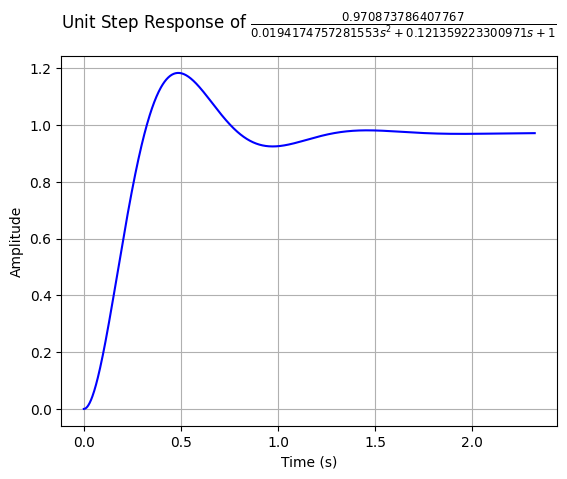

In [36]:
# Generic example with plot (distinct Km and Gm, add GL)
Km_ = TF(Km,1,s)
Gc = TF(Kc,1,s)
Ga = TF(Ka,taua*s+1,s)
Gp = TF(Kp,taup*s+1,s)
Gm = TF(Km,1,s)
GL = TF(KL,taup*s+1,s)
Gol = Series(Gc,Ga,Gp)
Gsc = Feedback(Gol,Gm)
Gsc = Series(Gsc,Km_)
Gsc = tbformat(Gsc.doit().simplify())

Gsc_ = Gsc.subs({Km:16/3, Kc:5000, Ka:-6/1600, taua:10/60, Kp:-1/3, taup:4, KL:1/4})

# Extracting the parameters (gain, tau and zeta)
gain = Gsc_.num.coeff(s, 0)
tau = Gsc_.den.coeff(s, 2)**0.5
zeta = Gsc_.den.coeff(s, 1)/2/tau

# Printing unit step response
upper_limit=(15*tau/((1-zeta**2)**0.5) if zeta < 1.0 else 9*tau)
step_response_plot(Gsc_, upper_limit=upper_limit)


In [37]:
Gsc

TransferFunction(K_a*K_c*K_m*K_p/(K_a*K_c*K_m*K_p + 1), s**2*tau_a*tau_p/(K_a*K_c*K_m*K_p + 1) + s*(tau_a + tau_p)/(K_a*K_c*K_m*K_p + 1) + 1, s)

In [38]:
print('Closed-loop servo control transfer function parameters')
print('- Static gain:   ', gain)
print('- Time constant: ', tau)
print('- Damping ratio: ', zeta)

Closed-loop servo control transfer function parameters
- Static gain:    0.970873786407767
- Time constant:  0.139346602858324
- Damping ratio:  0.435458133932261


In [39]:
import math
# Calculating time-domain features
OS = math.e**(-math.pi*zeta/((1-zeta**2)**0.5))
tp = math.pi*tau/((1-zeta**2)**0.5)
tr = tau/((1-zeta**2)**0.5)*(math.pi - math.cos(zeta))
print('Time-domain features')
print('- Overshoot:            ', OS)
print('- Peak time:            ', tp)
print('- Period of oscilation: ', 2*tp)
print('- Rise time:            ', tr)
print('- Settling times')
print('  +/-5%:                ', 3*tau/zeta)
print('  +/-2%:                ', 4*tau/zeta)
print('- Decay ratio:          ', OS**2)

Time-domain features
- Overshoot:             0.218781281581549
- Peak time:             0.486298483984800
- Period of oscilation:  0.972596967969600
- Rise time:             0.345950691279933
- Settling times
  +/-5%:                 0.960000000000000
  +/-2%:                 1.28000000000000
- Decay ratio:           0.0478652491704652
